In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/pcolina/pitch_2mm_diam_10um/")
filenames = sorted(path.glob("*.h5"))
filename  = filenames[0]
len(filenames)

10

In [4]:
testdf = imgs_from_file(filename)
testdf

,x0,y0,z0,r0,image
event,,,,,
0,13.778246,7.645318,-5.177589,15.757251,"[[[1, 2, 3, 2, 0], [0, 1, 0, 2, 1], [0, 6, 14,..."
1,3.292558,-9.625698,-5.183970,10.173250,"[[[7, 10, 4, 4, 0], [17, 18, 11, 12, 2], [6, 2..."
2,-1.823845,3.480703,-5.192792,3.929594,"[[[2, 12, 11, 13, 8], [8, 20, 24, 20, 11], [5,..."
3,11.789647,7.977518,-5.171978,14.235047,"[[[1, 0, 1, 1, 2], [2, 2, 4, 9, 7], [1, 6, 7, ..."
4,-0.603692,-2.781959,-5.170578,2.846706,"[[[6, 17, 10, 9, 6], [11, 23, 24, 16, 13], [10..."
...,...,...,...,...,...
49995,8.624991,9.071628,-5.195857,12.517384,"[[[0, 2, 2, 4, 2], [1, 3, 11, 13, 6], [2, 4, 1..."
49996,2.484213,13.473919,-5.186830,13.701014,"[[[0, 0, 3, 4, 6], [2, 4, 10, 15, 19], [1, 5, ..."
49997,-8.363537,0.250757,-5.196943,8.367295,"[[[13, 17, 30, 13, 9], [11, 17, 29, 18, 17], [..."


In [5]:
config    = simconfig(filename)
sipm_pos  = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[0]
sipm_x    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[1]
sipm_y    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[2]
extents   = sipm_extent   (config.sipm_size, config.sipm_gap, config.n_sipm_side)
ticks     = np.arange(-15, 16, 10) if config.el_diam==32 else np.arange(-30, 31, 15)

rmax   = config.el_diam/2
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)

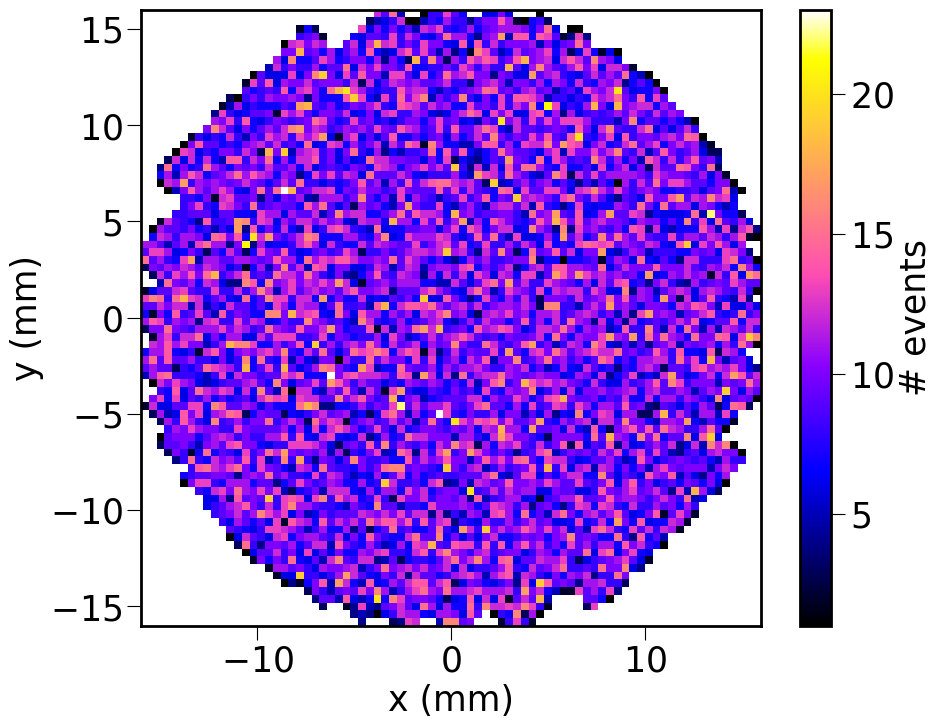

In [6]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

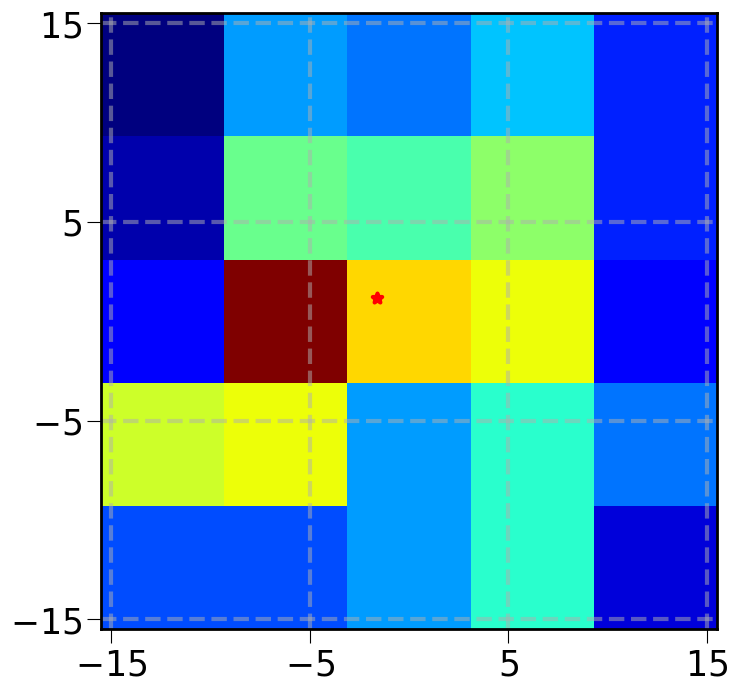

In [7]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

# Barycenter

In [8]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [9]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,5.160694,3.117919,13.778246,7.645318,-5.177589,15.757251,-8.617552,-4.527399,9.734452
1,-0.931606,-2.826943,3.292558,-9.625698,-5.183970,10.173250,-4.224164,6.798755,8.004164
2,-0.930000,1.123750,-1.823845,3.480703,-5.192792,3.929594,0.893845,-2.356953,2.520751
3,5.698266,2.365318,11.789647,7.977518,-5.171978,14.235047,-6.091381,-5.612200,8.282615
4,-2.118149,-0.683986,-0.603692,-2.781959,-5.170578,2.846706,-1.514457,2.097973,2.587484
...,...,...,...,...,...,...,...,...,...
49995,2.930909,5.749091,8.624991,9.071628,-5.195857,12.517384,-5.694082,-3.322537,6.592558
49996,1.596567,5.987124,2.484213,13.473919,-5.186830,13.701014,-0.887647,-7.486794,7.539231
49997,-5.166667,0.446212,-8.363537,0.250757,-5.196943,8.367295,3.196870,0.195455,3.202839


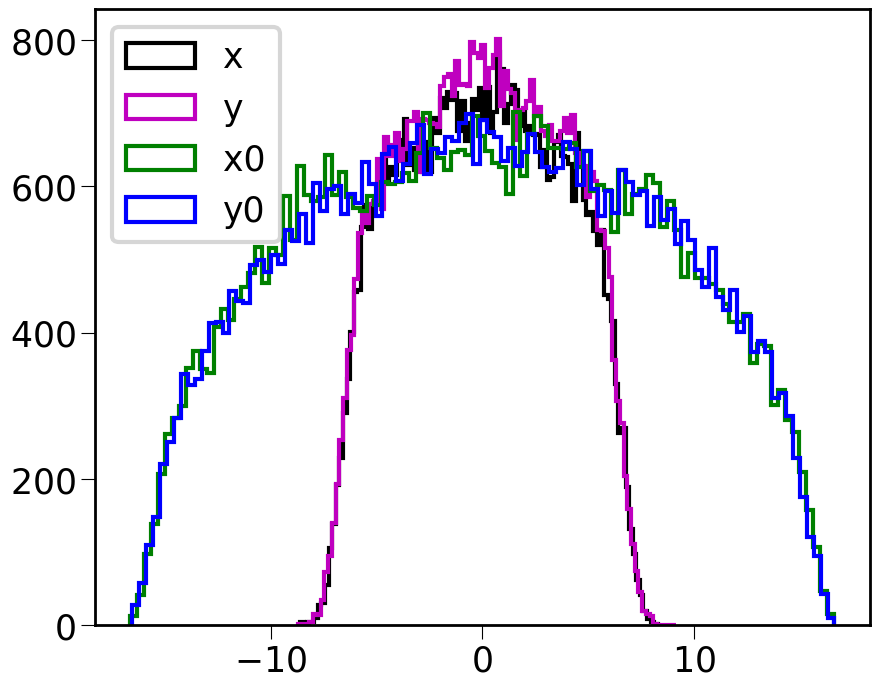

In [10]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

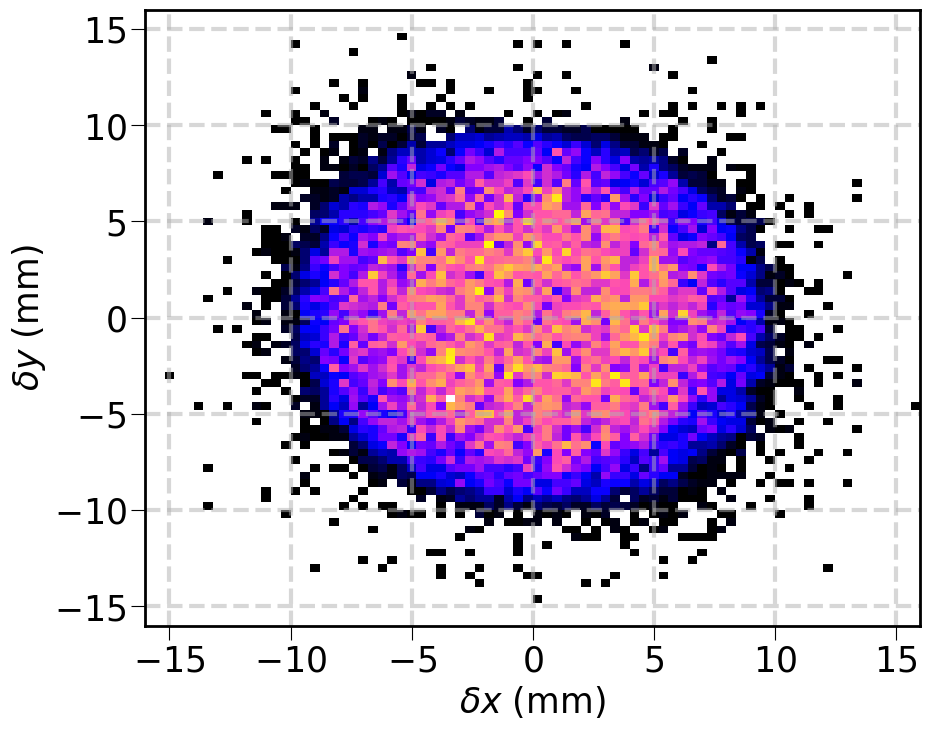

In [11]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

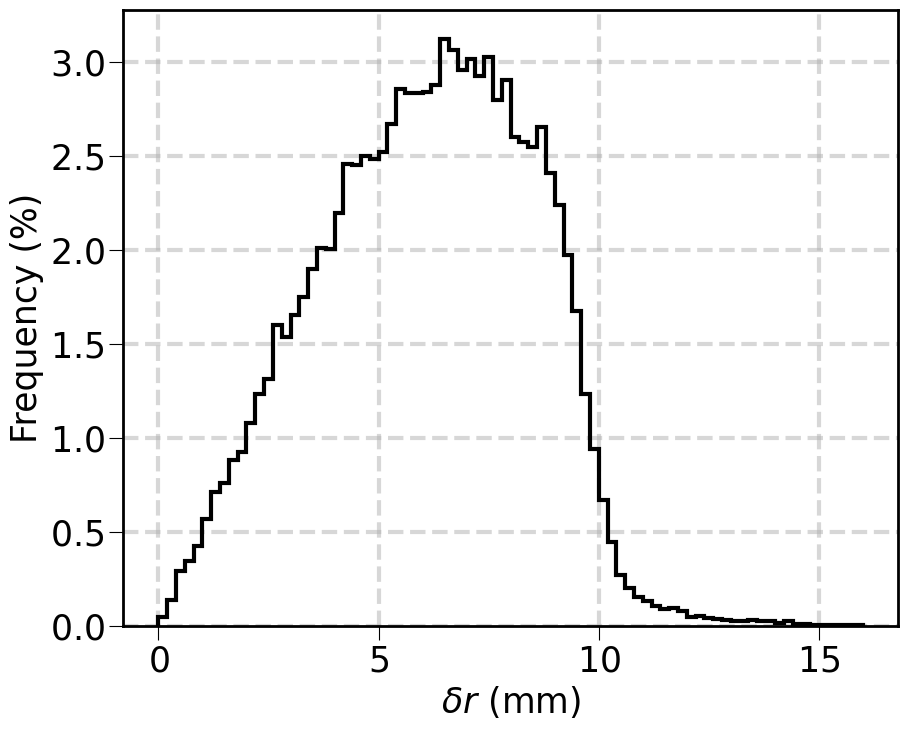

In [12]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

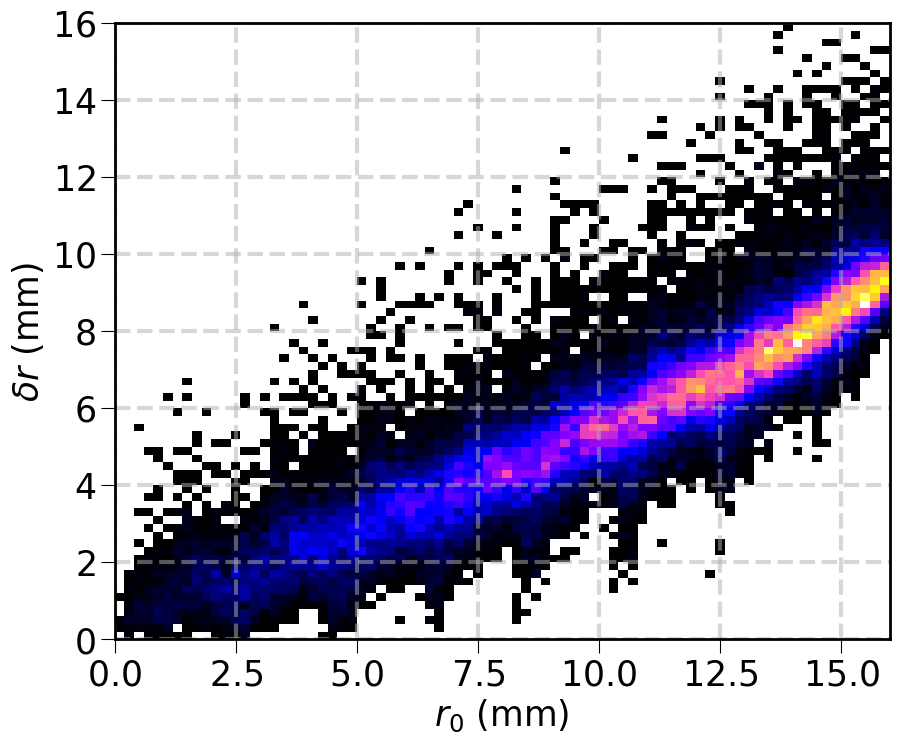

In [13]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

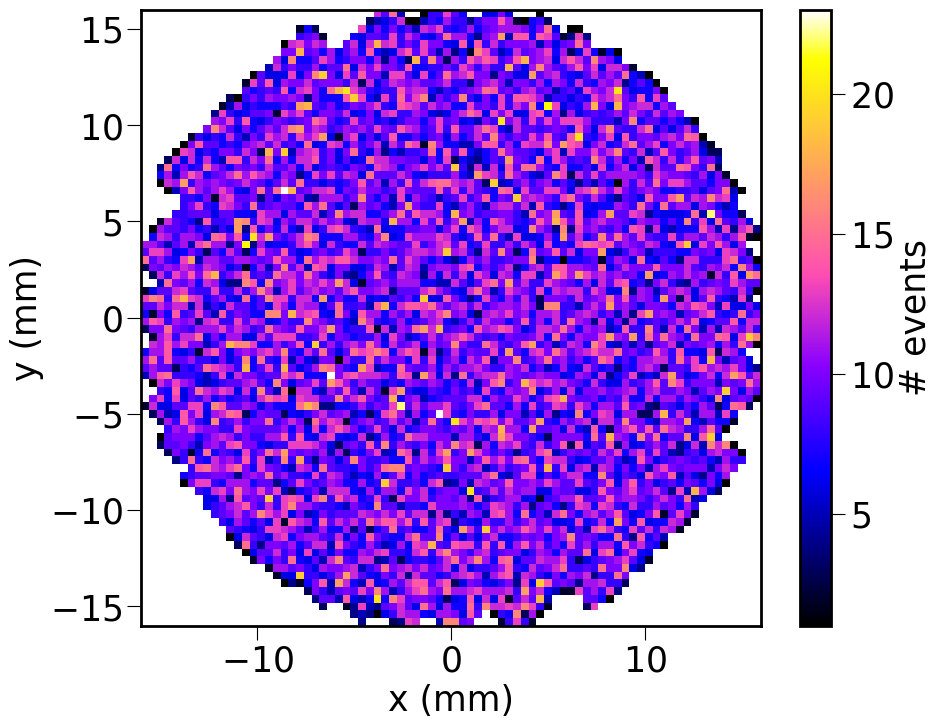

In [14]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

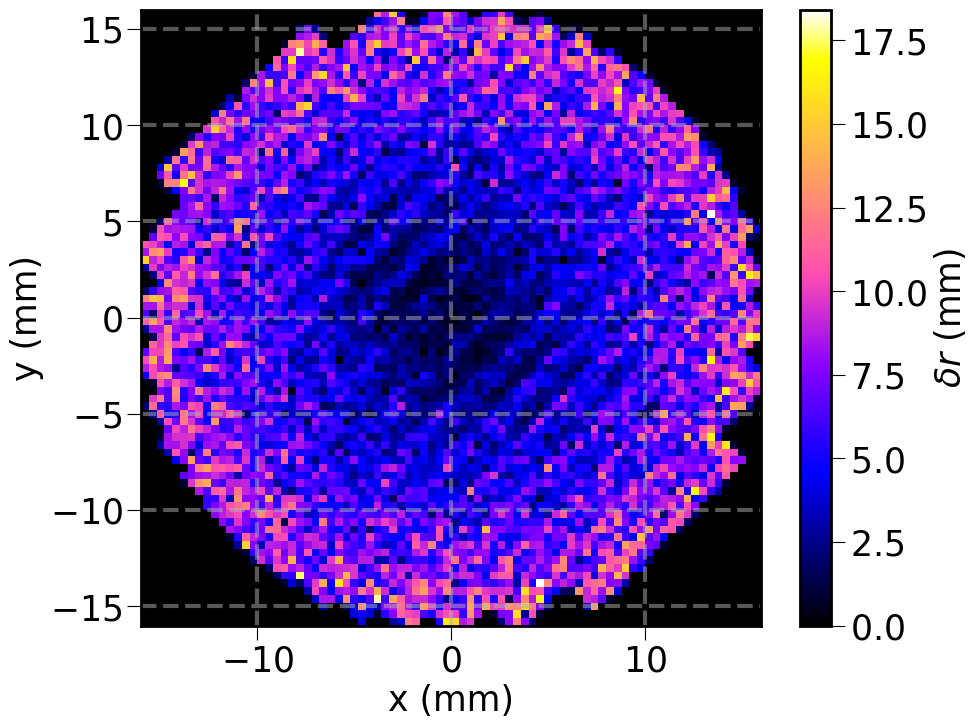

In [15]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

In [17]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [18]:
nfiles    = len(filenames)
train     = pd.concat([imgs_from_file(filename) for filename in filenames[:nfiles//2 ]])
test      = pd.concat([imgs_from_file(filename) for filename in filenames[ nfiles//2:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [19]:
model     = Linear(config.n_sipm_side, config.n_sipm_side)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
epochs = 500
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 500 of 500 | 0.26 s/item | ETA 0.0 min | Ellapsed 2.1 min


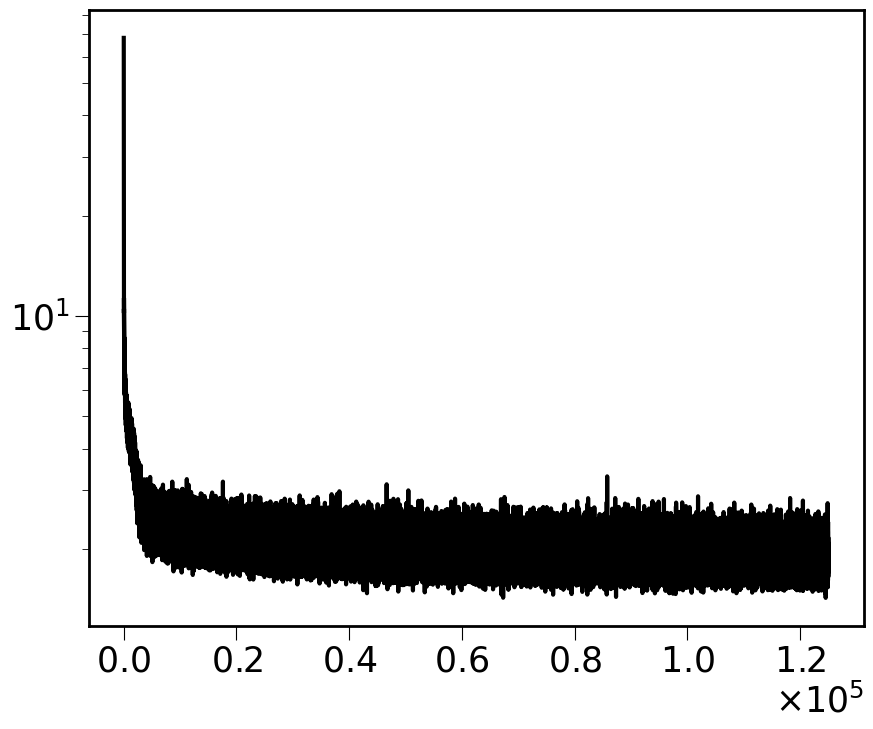

In [21]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [22]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

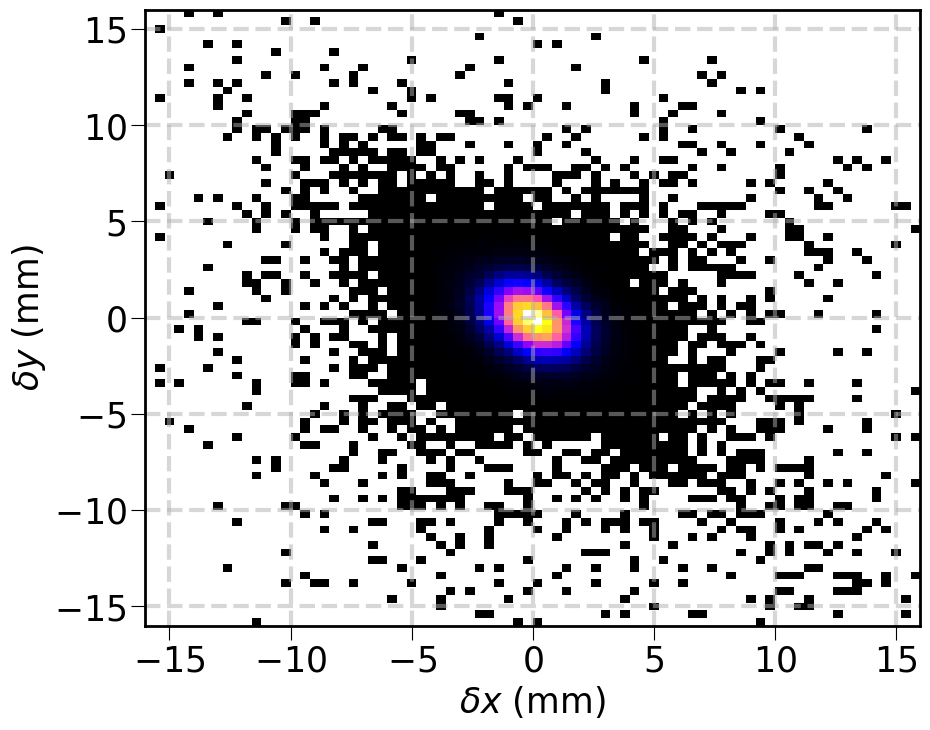

In [23]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

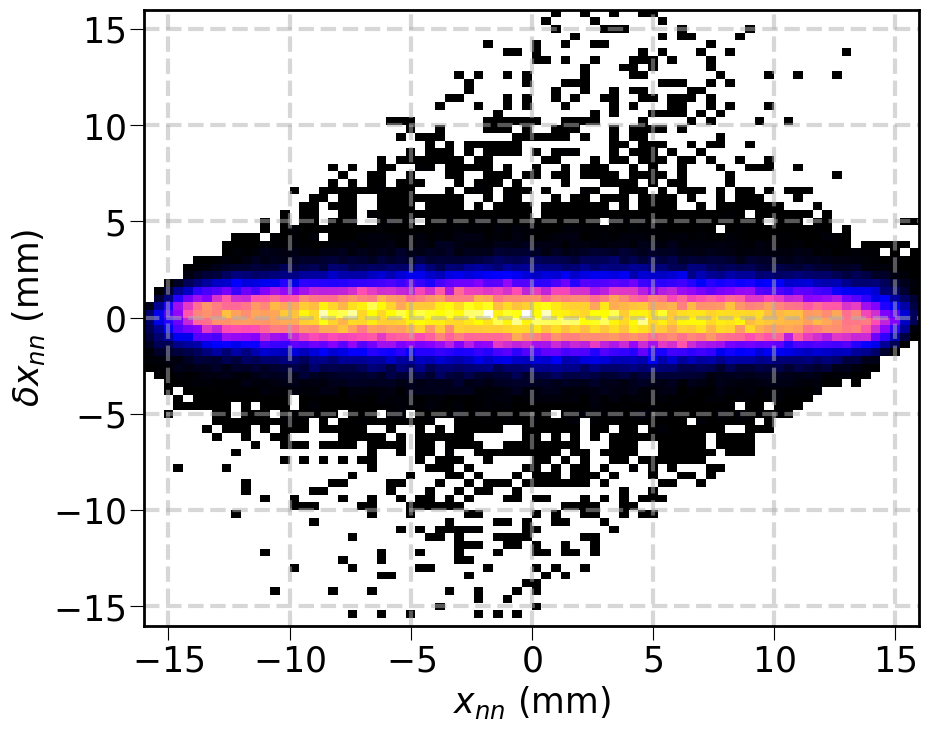

In [24]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_{nn}$ (mm)")
plt.ylabel("$\delta x_{nn}$ (mm)")
plt.grid()

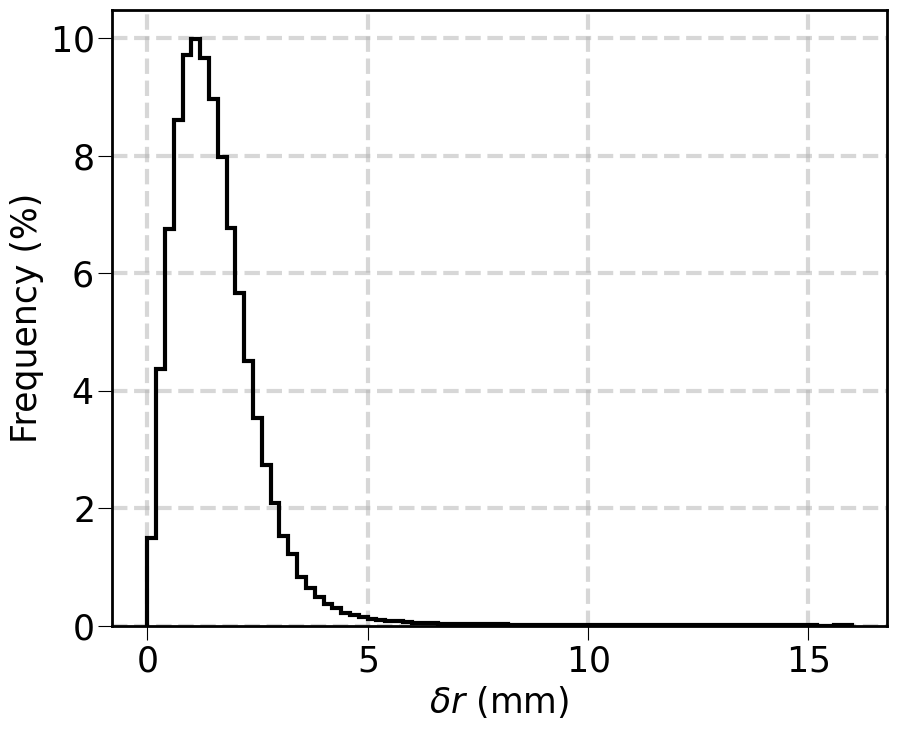

In [25]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

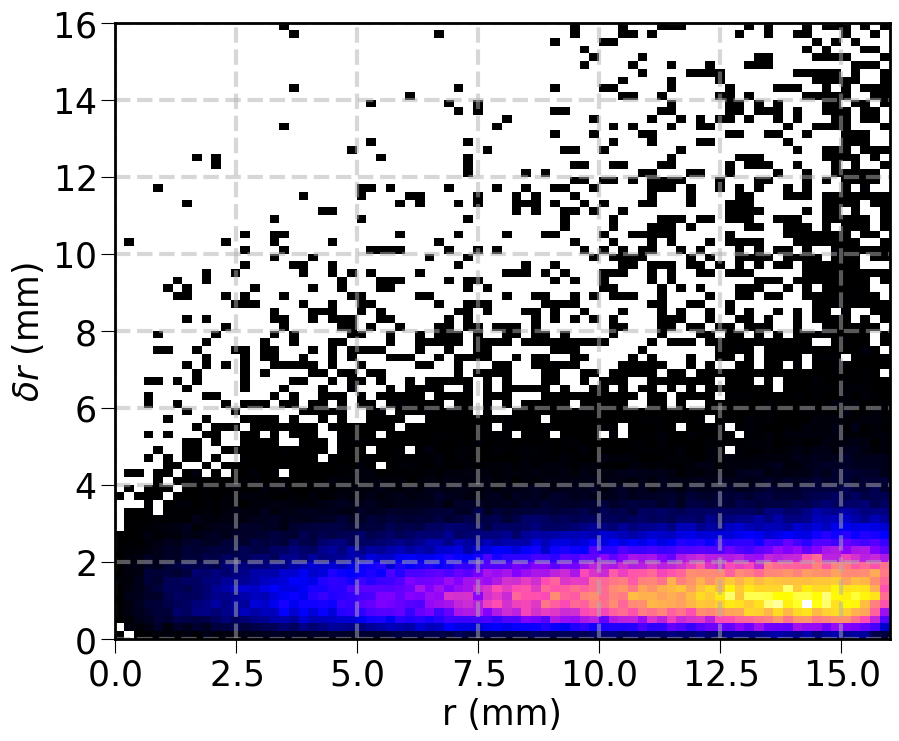

In [26]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

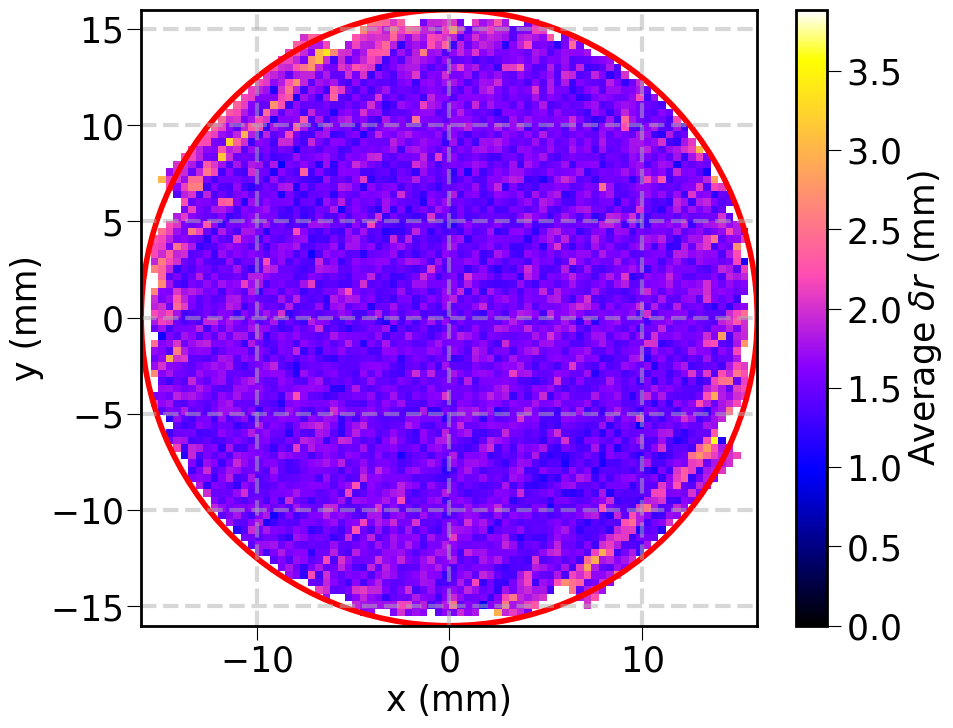

In [27]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=2.5*np.median(errs[errs>0]), extent=extents)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("Average $\delta r$ (mm)")
draw_el(plt.gca(), rmax)
plt.grid()

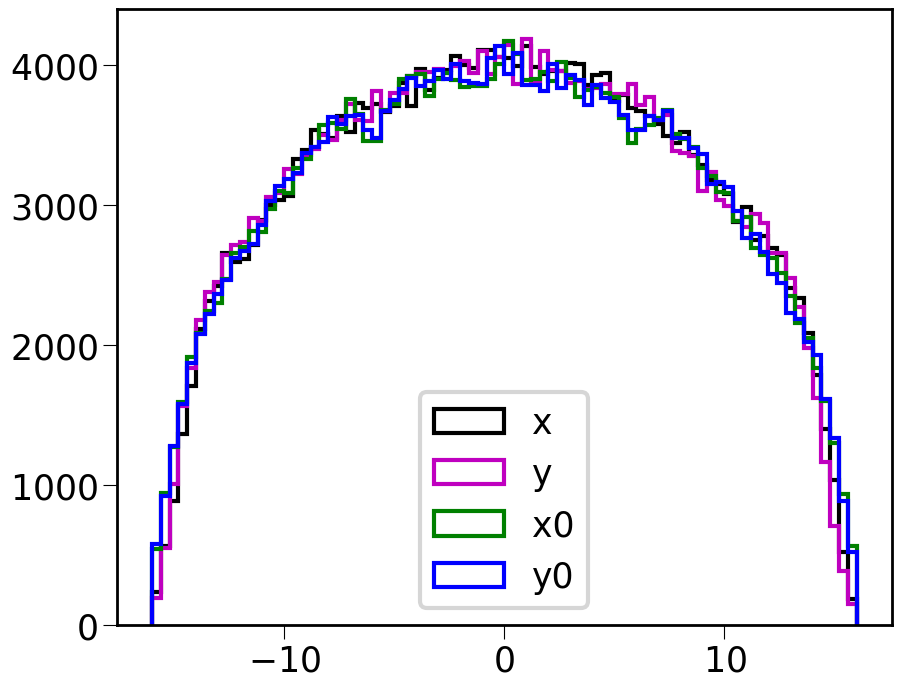

In [28]:
plt.hist(reco_nn.x , xybins, histtype="step", label="x");
plt.hist(reco_nn.y , xybins, histtype="step", label="y");
plt.hist(reco_nn.x0, xybins, histtype="step", label="x0");
plt.hist(reco_nn.y0, xybins, histtype="step", label="y0");
plt.legend()

In [31]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,9.836839,-9.100352,13.400739,8.417578,-7.358094,-1.419262,1.742258,2.247169
1,-2.564628,-6.441743,6.933496,-1.995306,-9.044866,0.569322,-2.603123,2.664653
2,14.301740,3.084755,14.630635,13.894539,3.368315,-0.407201,0.283560,0.496204
3,6.161843,2.000706,6.478513,6.446146,2.701888,0.284303,0.701182,0.756627
4,4.526577,9.248725,10.297029,5.969682,7.937753,1.443104,-1.310972,1.949666
...,...,...,...,...,...,...,...,...
49995,9.287420,0.614000,9.307694,9.719641,-1.594489,0.432220,-2.208490,2.250387
49996,-4.385093,6.216424,7.607428,-3.048044,5.220886,1.337049,-0.995538,1.666972
49997,8.818044,1.371592,8.924078,8.639540,2.053766,-0.178504,0.682175,0.705143


In [29]:
output = filenames[0].parent
output = output.parent / (output.stem + "_reco_summary.h5")
reco_nn.to_hdf(output, key="/data", complib="zlib", complevel=4, mode="w")

In [30]:
import datetime
print(f"Last execution: {datetime.datetime.now()}")

Last execution: 2026-03-03 11:37:11.267387
